In [1]:
# --- Naive Bayes Classification (Text + Price category) ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

text_col = "catalog_content"
target_col = "price"
# Preprocess text data EVEN THOUGH ITS ALL READY PRESPROCESSED (Just to be safe)
df[text_col] = df[text_col].fillna("").astype(str)
test_df[text_col] = test_df[text_col].fillna("").astype(str)

print(df.head())


   sample_id                                    catalog_content  \
0      33127  Item Name: La Victoria Green Taco Sauce Mild, ...   
1     198967  Item Name: Salerno Cookies, The Original Butte...   
2     261251  Item Name: Bear Creek Hearty Soup Bowl, Creamy...   
3      55858  Item Name: Judee’s Blue Cheese Powder 11.25 oz...   
4     292686  Item Name: kedem Sherry Cooking Wine, 12.7 Oun...   

                                          image_link  price  
0  https://m.media-amazon.com/images/I/51mo8htwTH...   4.89  
1  https://m.media-amazon.com/images/I/71YtriIHAA...  13.12  
2  https://m.media-amazon.com/images/I/51+PFEe-w-...   1.97  
3  https://m.media-amazon.com/images/I/41mu0HAToD...  30.34  
4  https://m.media-amazon.com/images/I/41sA037+Qv...  66.49  


In [3]:

df["price_class"] = pd.qcut(df[target_col], q=3, labels=["Low", "Medium", "High"])
print(df["price_class"].value_counts())


price_class
Low       25393
High      24952
Medium    24655
Name: count, dtype: int64


In [4]:
# Train-test split
X_train, X_val, y_train, y_val = train_test_split(
    df[text_col], df["price_class"], test_size=0.2, random_state=42
)

# TF-IDF vectorizer for text data
vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

print("TF-IDF shape:", X_train_tfidf.shape)


TF-IDF shape: (60000, 5000)


In [5]:
# Multinomial Naive Bayes (best for word counts / TF-IDF)
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# Predictions
y_pred = model.predict(X_val_tfidf)


✅ Accuracy: 54.95%

Classification Report:
               precision    recall  f1-score   support

        High       0.65      0.39      0.49      4997
         Low       0.54      0.75      0.63      5098
      Medium       0.50      0.50      0.50      4905

    accuracy                           0.55     15000
   macro avg       0.56      0.55      0.54     15000
weighted avg       0.56      0.55      0.54     15000



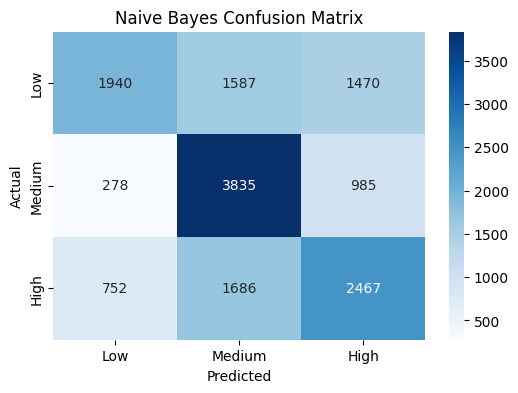

In [6]:
# Evaluation metrics
acc = accuracy_score(y_val, y_pred)
cm = confusion_matrix(y_val, y_pred)
print(f"✅ Accuracy: {acc*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_val, y_pred))

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low","Medium","High"],
            yticklabels=["Low","Medium","High"])
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [7]:
# Transform test data
X_test_tfidf = vectorizer.transform(test_df[text_col])

# Predict price class for test data
test_pred = model.predict(X_test_tfidf)
test_df["predicted_price_class"] = test_pred

test_df.to_csv("test_naive_bayes_predictions.csv", index=False)
print("💾 Saved test predictions to 'test_naive_bayes_predictions.csv'")


💾 Saved test predictions to 'test_naive_bayes_predictions.csv'
